In [1]:
!pip install tensorflow matplotlib albumentations

In [4]:
!pip install --upgrade albumentations

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from albumentations import Compose, RandomRotate90, HorizontalFlip, VerticalFlip, ShiftScaleRotate

In [8]:
# Load MNIST dataset
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize the data to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten images
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
# Define augmentation pipeline
from albumentations import Compose, RandomRotate90, HorizontalFlip, VerticalFlip, ShiftScaleRotate
augmentation_pipeline = Compose([
    RandomRotate90(),
    HorizontalFlip(),  # or VerticalFlip() or both in a list
    ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5)
])

# Apply augmentation to a subset of training images
def augment_images(images):
    augmented_images = []
    for img in images[:5000]:  # Augment first 5000 samples
        img_reshaped = img.reshape(28, 28, 1)
        augmented = augmentation_pipeline(image=img_reshaped)['image']
        augmented_images.append(augmented.flatten())
    return np.array(augmented_images)

X_train_augmented = augment_images(X_train)
X_train_combined = np.vstack((X_train, X_train_augmented))

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [15]:
class RBM:
    def __init__(self, n_visible, n_hidden):
        self.n_visible = n_visible
        self.n_hidden = n_hidden

        # Initialize weights and biases
        self.W = tf.Variable(tf.random.normal([n_visible, n_hidden], stddev=0.01))
        self.bv = tf.Variable(tf.zeros([n_visible]))
        self.bh = tf.Variable(tf.zeros([n_hidden]))

    def forward(self, visible):
        return tf.nn.sigmoid(tf.matmul(visible, self.W) + self.bh)

    def backward(self, hidden):
        return tf.nn.sigmoid(tf.matmul(hidden, tf.transpose(self.W)) + self.bv)

    def train(self, data, learning_rate=0.01, epochs=10, batch_size=64):
        dataset = tf.data.Dataset.from_tensor_slices(data).batch(batch_size)

        for epoch in range(epochs):
            for batch in dataset:
                # Positive phase
                hidden_probs = self.forward(batch)
                hidden_states = tf.nn.relu(tf.sign(hidden_probs - tf.random.uniform(tf.shape(hidden_probs))))

                # Negative phase
                visible_recon = self.backward(hidden_states)
                hidden_recon_probs = self.forward(visible_recon)

                # Compute gradients
                pos_grad = tf.matmul(tf.transpose(batch), hidden_probs)
                neg_grad = tf.matmul(tf.transpose(visible_recon), hidden_recon_probs)

                # Update weights and biases
                self.W.assign_add(learning_rate * (pos_grad - neg_grad) / tf.cast(tf.shape(batch)[0], tf.float32))
                self.bv.assign_add(learning_rate * tf.reduce_mean(batch - visible_recon, axis=0))
                self.bh.assign_add(learning_rate * tf.reduce_mean(hidden_probs - hidden_recon_probs, axis=0))

            print(f"Epoch {epoch + 1}/{epochs} completed.")

In [16]:
# Initialize the first RBM
rbm1 = RBM(n_visible=X_train_combined.shape[1], n_hidden=256)

# Train the first RBM
rbm1.train(X_train_combined, learning_rate=0.01, epochs=10, batch_size=128)

Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


In [17]:
# Transform data using the first RBM
hidden_features = rbm1.forward(X_train_combined)

# Initialize the second RBM
rbm2 = RBM(n_visible=256, n_hidden=128)

# Train the second RBM
rbm2.train(hidden_features.numpy(), learning_rate=0.01, epochs=10, batch_size=128)

Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


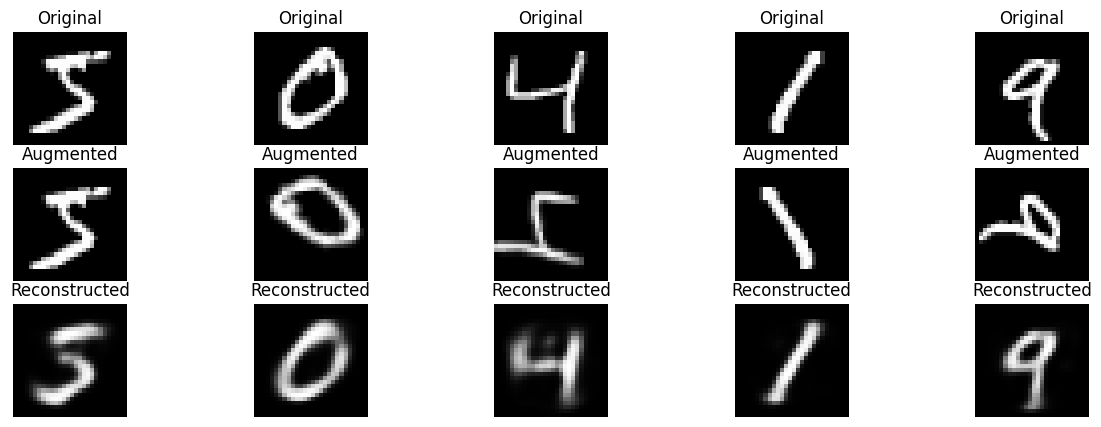

In [18]:
# Reconstruct using the first RBM
reconstructed = rbm1.backward(hidden_features).numpy()

# Plot original, augmented, and reconstructed images
def plot_images(original, augmented, reconstructed, n=5):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        # Original
        plt.subplot(3, n, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Augmented
        plt.subplot(3, n, n + i + 1)
        plt.imshow(augmented[i].reshape(28, 28), cmap='gray')
        plt.title("Augmented")
        plt.axis('off')

        # Reconstructed
        plt.subplot(3, n, 2 * n + i + 1)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()

plot_images(X_train[:5], X_train_augmented[:5], reconstructed[:5])

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Dummy labels for demonstration (replace with actual labels for real tasks)
labels = np.random.randint(0, 10, len(X_train_combined))

# Train logistic regression on RBM features
clf = LogisticRegression(max_iter=1000)
clf.fit(hidden_features.numpy(), labels)

# Predict on new features
test_features = rbm1.forward(X_test).numpy()
predictions = clf.predict(test_features)
print("Sample predictions:", predictions[:10])

Sample predictions: [4 0 3 2 7 4 5 3 0 6]
